In [1]:
import os
import numpy as np
import pandas as pd

try:
    import xarray as xr
except ImportError as exc:
    raise ImportError("xarray is required to read .nc files. Please install it in this environment.") from exc

print("xarray version:", xr.__version__)

xarray version: 2024.7.0


NOTE: First need to download files from: https://services.swpc.noaa.gov/netcdf/geoelectric/InterMagEarthScope/


In [2]:

# filename_noaa_geoE = '/Users/ryanmc/Documents/NASA_JPL/Projects/NaturalHazards/NASA ROSES Disasters 2025-2027/data/NOAA_geoE/20240101-empirical-EMTF-2022.12-2022.12.nc'
filename_noaa_geoE = '/Users/ryanmc/Documents/NASA_JPL/Projects/NaturalHazards/NASA ROSES Disasters 2025-2027/data/NOAA_geoE/20240411-empirical-EMTF-2022.12-2022.12.nc'


In [3]:
import os
import pandas as pd
import xarray as xr

if not os.path.exists(filename_noaa_geoE):
    raise FileNotFoundError(f"File not found: {filename_noaa_geoE}")

print("Reading:", filename_noaa_geoE)

# Open lazily, then load metadata-driven summary
ds_noaa_geoE = xr.open_dataset(filename_noaa_geoE)

print("\n=== DATASET OVERVIEW ===")
print(ds_noaa_geoE)

print("\n=== GLOBAL ATTRIBUTES ===")
if len(ds_noaa_geoE.attrs) == 0:
    print("No global attributes found.")
else:
    for key, value in ds_noaa_geoE.attrs.items():
        print(f"{key}: {value}")

print("\n=== DIMENSIONS ===")
for dim_name, dim_size in ds_noaa_geoE.sizes.items():
    print(f"{dim_name}: {dim_size}")

print("\n=== COORDINATES ===")
for coord_name, coord_da in ds_noaa_geoE.coords.items():
    print(f"{coord_name}: shape={coord_da.shape}, dtype={coord_da.dtype}")

print("\n=== DATA VARIABLES ===")
for var_name, var_da in ds_noaa_geoE.data_vars.items():
    print(f"\n{var_name}: shape={var_da.shape}, dtype={var_da.dtype}, dims={var_da.dims}")
    if len(var_da.attrs) > 0:
        for k, v in var_da.attrs.items():
            print(f"  - {k}: {v}")

# Build compact variable summary table
var_summary = pd.DataFrame(
    {
        "variable": list(ds_noaa_geoE.data_vars.keys()),
        "dims": [str(ds_noaa_geoE[v].dims) for v in ds_noaa_geoE.data_vars.keys()],
        "shape": [str(tuple(ds_noaa_geoE[v].shape)) for v in ds_noaa_geoE.data_vars.keys()],
        "dtype": [str(ds_noaa_geoE[v].dtype) for v in ds_noaa_geoE.data_vars.keys()],
    }
).sort_values("variable")

print("\n=== VARIABLE SUMMARY TABLE ===")
display(var_summary)

# Preview first variable values (small slice)
first_var = list(ds_noaa_geoE.data_vars.keys())[0] if len(ds_noaa_geoE.data_vars) > 0 else None
if first_var is not None:
    print(f"\n=== SAMPLE SLICE: {first_var} ===")
    da = ds_noaa_geoE[first_var]
    try:
        display(da.isel({d: 0 for d in da.dims if ds_noaa_geoE.sizes[d] > 1}).to_dataframe().head())
    except Exception:
        print(da.values.flat[:10])

# Keep dataset handle available for further exploration
print("\nDataset loaded as variable: ds_noaa_geoE")

Reading: /Users/ryanmc/Documents/NASA_JPL/Projects/NaturalHazards/NASA ROSES Disasters 2025-2027/data/NOAA_geoE/20240411-empirical-EMTF-2022.12-2022.12.nc

=== DATASET OVERVIEW ===
<xarray.Dataset> Size: 60MB
Dimensions:    (time: 1440, gridpt: 3432)
Coordinates:
  * time       (time) float64 12kB 30.0 90.0 150.0 ... 8.631e+04 8.637e+04
Dimensions without coordinates: gridpt
Data variables:
    nobs       (time) int32 6kB ...
    emax       (time) float64 12kB ...
    obslist    (time) |S401 577kB ...
    latitude   (gridpt) float32 14kB ...
    longitude  (gridpt) float32 14kB ...
    distance   (gridpt) float32 14kB ...
    Ex         (time, gridpt) float32 20MB ...
    Ey         (time, gridpt) float32 20MB ...
    Quality    (time, gridpt) float32 20MB ...
Attributes:
    FILENAME:       20240411-empirical-EMTF-2022.12-2022.12.nc
    MODEL_TYPE:     empirical-EMTF-2022.12
    MODEL_VERSION:  2022.12
    CADENCE:        60 seconds
    NGRIDPTS:       3432

=== GLOBAL ATTRIBUTES ===


,variable,dims,shape,dtype
6,Ex,"('time', 'gridpt')","(1440, 3432)",float32
7,Ey,"('time', 'gridpt')","(1440, 3432)",float32
8,Quality,"('time', 'gridpt')","(1440, 3432)",float32
5,distance,"('gridpt',)","(3432,)",float32
1,emax,"('time',)","(1440,)",float64
3,latitude,"('gridpt',)","(3432,)",float32
4,longitude,"('gridpt',)","(3432,)",float32
0,nobs,"('time',)","(1440,)",int32
2,obslist,"('time',)","(1440,)",|S401



=== SAMPLE SLICE: nobs ===
[14 14 14 14 14 14 14 14 14 14]

Dataset loaded as variable: ds_noaa_geoE


Using state boundaries file: /Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/location_data/Census_Bureau_Data/tl_2014_us_state/tl_2014_us_state.shp


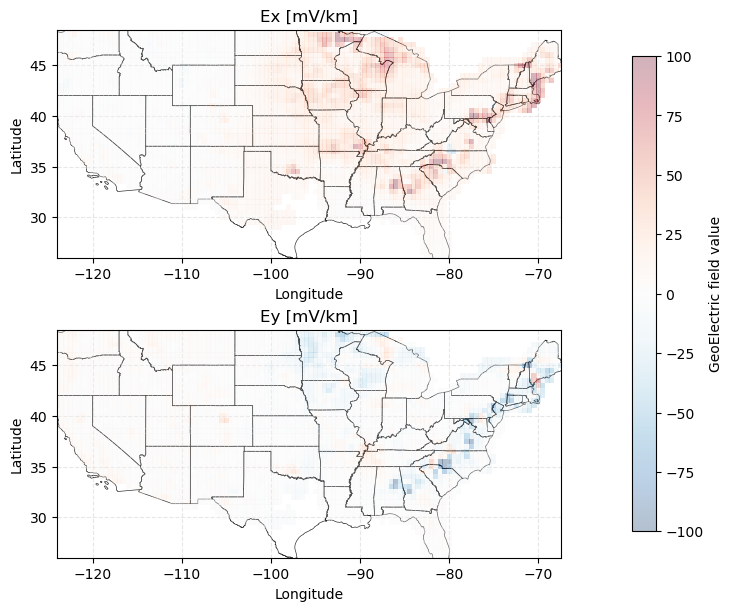

Mapped points: 3432
Detected fields -> time: time, lat: latitude, lon: longitude, Ex: Ex, Ey: Ey
Selected time_index=200, time=12030.0


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

# Config
time_index = 200
expected_points = 3432

# ---- Helper functions ----
def pick_name(candidates, options):
    for cand in candidates:
        for name in options:
            if cand in name.lower():
                return name
    return None


def reduce_to_point_vector(da, time_name=None, time_index=0, expected_points=3432):
    work = da

    if time_name is not None and time_name in work.dims:
        work = work.isel({time_name: time_index})

    point_dims = [d for d in work.dims if work.sizes[d] == expected_points]
    if len(point_dims) > 0:
        point_dim = point_dims[0]
        for dim in list(work.dims):
            if dim != point_dim:
                work = work.isel({dim: 0})
    else:
        if len(work.dims) > 0:
            point_dim = max(work.dims, key=lambda d: work.sizes[d])
            for dim in list(work.dims):
                if dim != point_dim:
                    work = work.isel({dim: 0})

    work = work.squeeze(drop=True)
    if work.ndim != 1:
        raise ValueError(f"Could not reduce {da.name} to 1D vector. Got shape={work.shape}, dims={work.dims}")

    return np.asarray(work.values, dtype=float)


# ---- Identify fields ----
coord_names = list(ds_noaa_geoE.coords)
var_names = list(ds_noaa_geoE.data_vars)

time_name = pick_name(["time"], coord_names)
lat_name = pick_name(["latitude", "lat"], var_names) or pick_name(["latitude", "lat"], coord_names)
lon_name = pick_name(["longitude", "lon", "long"], var_names) or pick_name(["longitude", "lon", "long"], coord_names)
ex_name = pick_name(["ex", "e_x"], var_names)
ey_name = pick_name(["ey", "e_y"], var_names)

if lat_name is None or lon_name is None or ex_name is None or ey_name is None:
    raise ValueError(
        f"Could not identify required fields. coords={coord_names}, vars={var_names}. "
        f"Detected time={time_name}, lat={lat_name}, lon={lon_name}, Ex={ex_name}, Ey={ey_name}"
    )

# ---- Extract vectors at selected time ----
lat_vec = reduce_to_point_vector(ds_noaa_geoE[lat_name], time_name=time_name, time_index=time_index, expected_points=expected_points)
lon_vec = reduce_to_point_vector(ds_noaa_geoE[lon_name], time_name=time_name, time_index=time_index, expected_points=expected_points)
ex_vec = reduce_to_point_vector(ds_noaa_geoE[ex_name], time_name=time_name, time_index=time_index, expected_points=expected_points)
ey_vec = reduce_to_point_vector(ds_noaa_geoE[ey_name], time_name=time_name, time_index=time_index, expected_points=expected_points)

valid = np.isfinite(lat_vec) & np.isfinite(lon_vec) & np.isfinite(ex_vec) & np.isfinite(ey_vec)
lat_vec = lat_vec[valid]
lon_vec = lon_vec[valid]
ex_vec = ex_vec[valid]
ey_vec = ey_vec[valid]

cmax = 100 #np.nanmax(np.abs(np.r_[ex_vec, ey_vec]))

# ---- Load state boundaries without Cartopy ----
# Prioritize full U.S. Census state shapefile provided by user.
state_boundaries_gdf = None
state_candidates = [
    "/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/location_data/Census_Bureau_Data/tl_2014_us_state/tl_2014_us_state.shp",
    os.path.join("data", "selected_states_May2024_event.geojson"),
    os.path.join("data", "selected_states_MarchApril2023_event.geojson"),
    os.path.join("data", "ca_and_bordering_states.geojson"),
    os.path.join("..", "data", "selected_states_May2024_event.geojson"),
    os.path.join("..", "data", "selected_states_MarchApril2023_event.geojson"),
    os.path.join("..", "data", "ca_and_bordering_states.geojson"),
]

for candidate in state_candidates:
    if os.path.exists(candidate):
        state_boundaries_gdf = gpd.read_file(candidate)
        if state_boundaries_gdf.crs is not None and str(state_boundaries_gdf.crs) != "EPSG:4326":
            state_boundaries_gdf = state_boundaries_gdf.to_crs("EPSG:4326")
        print(f"Using state boundaries file: {candidate}")
        break

# ---- Plot side-by-side maps (no Cartopy required) ----
fig, axes = plt.subplots(2, 1, figsize=(16, 6), constrained_layout=True)

if state_boundaries_gdf is not None:
    for ax in axes:
        state_boundaries_gdf.boundary.plot(ax=ax, color="black", linewidth=0.5, alpha=0.8, zorder=1)

sc0 = axes[0].scatter(
    lon_vec,
    lat_vec,
    c=ex_vec,
    s=14,
    cmap="RdBu_r",
    vmin=-cmax,
    vmax=cmax,
    marker="s",
    linewidths=0,
    zorder=2,
    alpha=0.3
)
axes[0].set_title(f"{ex_name} [mV/km]")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].grid(True, linestyle="--", alpha=0.3)

sc1 = axes[1].scatter(
    lon_vec,
    lat_vec,
    c=ey_vec,
    s=14,
    cmap="RdBu_r",
    vmin=-cmax,
    vmax=cmax,
    marker="s",
    linewidths=0,
    zorder=2,
    alpha=0.3
)
axes[1].set_title(f"{ey_name} [mV/km]")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].grid(True, linestyle="--", alpha=0.3)

xmin, xmax = np.nanmin(lon_vec), np.nanmax(lon_vec)
ymin, ymax = np.nanmin(lat_vec), np.nanmax(lat_vec)
for ax in axes:
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

cbar = fig.colorbar(sc1, ax=axes.ravel().tolist(), shrink=0.9)
cbar.set_label("GeoElectric field value")

plt.show()

print(f"Mapped points: {len(lat_vec)}")
print(f"Detected fields -> time: {time_name}, lat: {lat_name}, lon: {lon_name}, Ex: {ex_name}, Ey: {ey_name}")
if time_name is not None:
    time_vals = ds_noaa_geoE[time_name].values
    if len(time_vals) > time_index:
        print(f"Selected time_index={time_index}, time={time_vals[time_index]}")
if state_boundaries_gdf is None:
    print("No state boundary file found. Check the Census shapefile path or add a local GeoJSON under data/.")

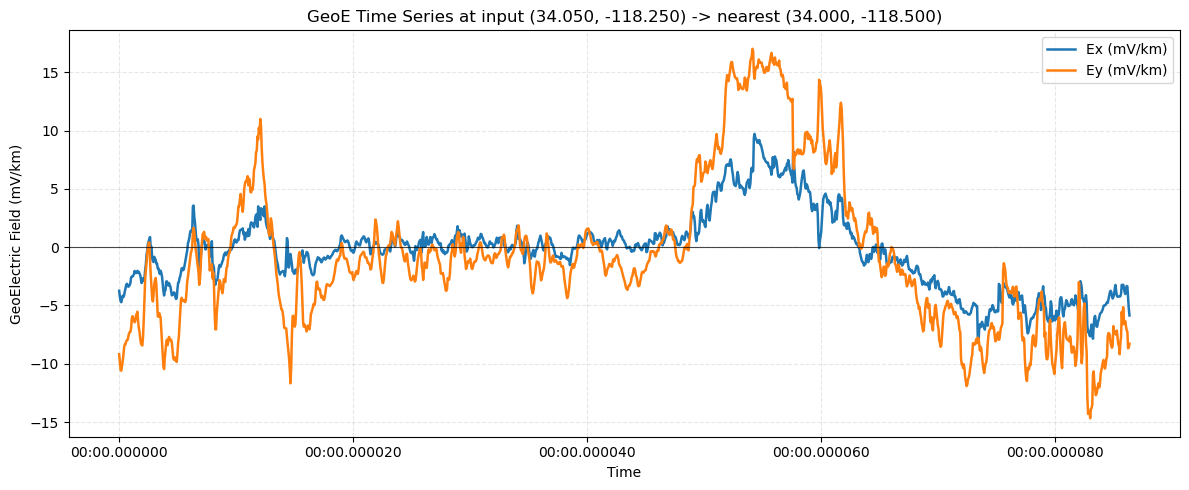

,time,ex_mV_per_km,ey_mV_per_km,input_lat,input_lon,matched_lat,matched_lon,point_distance_deg
0,1970-01-01 00:00:00.000000030,-3.741846,-9.179315,34.05,-118.25,34.0,-118.5,0.254951
1,1970-01-01 00:00:00.000000090,-4.246920,-9.851236,34.05,-118.25,34.0,-118.5,0.254951
2,1970-01-01 00:00:00.000000150,-4.614049,-10.540333,34.05,-118.25,34.0,-118.5,0.254951
3,1970-01-01 00:00:00.000000210,-4.722195,-10.593560,34.05,-118.25,34.0,-118.5,0.254951
4,1970-01-01 00:00:00.000000270,-4.449978,-10.221920,34.05,-118.25,34.0,-118.5,0.254951


Returned dataframe rows: 1440


In [ ]:
# get GeoE time series (Ex, Ey) at nearest model point to an input lat/lon
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def get_geoe_timeseries_at_latlon(ds, latitude, longitude, expected_points=3432, make_plot=True):
    """
    Return GeoE time series (Ex, Ey) at the nearest grid point to (latitude, longitude).

    Parameters
    ----------
    ds : xarray.Dataset
        Dataset containing lat/lon and GeoE Ex/Ey fields.
    latitude : float
        Target latitude in degrees.
    longitude : float
        Target longitude in degrees.
    expected_points : int
        Typical number of spatial points (used to identify point dimension).
    make_plot : bool
        If True, plot Ex and Ey over time.

    Returns
    -------
    df : pandas.DataFrame
        Columns: time, ex_mV_per_km, ey_mV_per_km, input_lat, input_lon, matched_lat, matched_lon, point_distance_deg
    """

    def pick_name(candidates, options):
        for cand in candidates:
            for name in options:
                if cand in name.lower():
                    return name
        return None

    def to_1d(da):
        work = da

        # Remove time if present in coordinate variables
        if time_name is not None and time_name in work.dims and work.sizes[time_name] > 1:
            work = work.isel({time_name: 0})

        # Reduce to the point dimension
        point_dims = [d for d in work.dims if work.sizes[d] == expected_points]
        if len(point_dims) > 0:
            point_dim = point_dims[0]
        else:
            point_dim = max(work.dims, key=lambda d: work.sizes[d])

        for dim in list(work.dims):
            if dim != point_dim:
                work = work.isel({dim: 0})

        work = work.squeeze(drop=True)
        if work.ndim != 1:
            raise ValueError(f"Could not reduce {da.name} to 1D. shape={work.shape}, dims={work.dims}")

        return np.asarray(work.values, dtype=float), point_dim

    coord_names = list(ds.coords)
    var_names = list(ds.data_vars)

    time_name = pick_name(["time"], coord_names)
    lat_name = pick_name(["latitude", "lat"], var_names) or pick_name(["latitude", "lat"], coord_names)
    lon_name = pick_name(["longitude", "lon", "long"], var_names) or pick_name(["longitude", "lon", "long"], coord_names)
    ex_name = pick_name(["ex", "e_x"], var_names)
    ey_name = pick_name(["ey", "e_y"], var_names)

    if lat_name is None or lon_name is None or ex_name is None or ey_name is None or time_name is None:
        raise ValueError(
            f"Could not identify required fields. coords={coord_names}, vars={var_names}. "
            f"Detected time={time_name}, lat={lat_name}, lon={lon_name}, Ex={ex_name}, Ey={ey_name}"
        )

    # 1) Build point coordinates and find nearest point index
    lat_vec, point_dim_lat = to_1d(ds[lat_name])
    lon_vec, point_dim_lon = to_1d(ds[lon_name])

    if point_dim_lat != point_dim_lon:
        raise ValueError(f"Lat/Lon point dimension mismatch: {point_dim_lat} vs {point_dim_lon}")
    point_dim = point_dim_lat

    valid = np.isfinite(lat_vec) & np.isfinite(lon_vec)
    if not np.any(valid):
        raise ValueError("No valid lat/lon points found in dataset.")

    d2 = (lat_vec[valid] - latitude) ** 2 + (lon_vec[valid] - longitude) ** 2
    valid_indices = np.where(valid)[0]
    nearest_idx = valid_indices[int(np.argmin(d2))]

    matched_lat = float(lat_vec[nearest_idx])
    matched_lon = float(lon_vec[nearest_idx])
    point_distance_deg = float(np.sqrt(np.min(d2)))

    # 2) Extract Ex/Ey time series at that point
    ex_da = ds[ex_name]
    ey_da = ds[ey_name]

    if point_dim not in ex_da.dims or point_dim not in ey_da.dims:
        raise ValueError(
            f"Point dimension '{point_dim}' not present in Ex/Ey dims. Ex dims={ex_da.dims}, Ey dims={ey_da.dims}"
        )
    if time_name not in ex_da.dims or time_name not in ey_da.dims:
        raise ValueError(
            f"Time dimension '{time_name}' not present in Ex/Ey dims. Ex dims={ex_da.dims}, Ey dims={ey_da.dims}"
        )

    ex_series = ex_da.isel({point_dim: nearest_idx})
    ey_series = ey_da.isel({point_dim: nearest_idx})

    # Remove any extra singleton dims
    for dim in list(ex_series.dims):
        if dim != time_name:
            ex_series = ex_series.isel({dim: 0})
    for dim in list(ey_series.dims):
        if dim != time_name:
            ey_series = ey_series.isel({dim: 0})

    time_vals = pd.to_datetime(ds[time_name].values)
    ex_vals = np.asarray(ex_series.values, dtype=float)
    ey_vals = np.asarray(ey_series.values, dtype=float)

    if len(ex_vals) != len(time_vals) or len(ey_vals) != len(time_vals):
        raise ValueError(
            f"Length mismatch: time={len(time_vals)}, Ex={len(ex_vals)}, Ey={len(ey_vals)}"
        )

    df = pd.DataFrame(
        {
            "time": time_vals,
            "ex_mV_per_km": ex_vals,
            "ey_mV_per_km": ey_vals,
            "input_lat": float(latitude),
            "input_lon": float(longitude),
            "matched_lat": matched_lat,
            "matched_lon": matched_lon,
            "point_distance_deg": point_distance_deg,
        }
    )

    if make_plot:
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(df["time"], df["ex_mV_per_km"], label="Ex (mV/km)", linewidth=1.8, color="tab:blue")
        ax.plot(df["time"], df["ey_mV_per_km"], label="Ey (mV/km)", linewidth=1.8, color="tab:orange")
        ax.axhline(0, color="black", linewidth=0.8, alpha=0.7)
        ax.set_title(
            f"GeoE Time Series at input ({latitude:.3f}, {longitude:.3f}) -> nearest ({matched_lat:.3f}, {matched_lon:.3f})"
        )
        ax.set_xlabel("Time")
        ax.set_ylabel("GeoElectric Field (mV/km)")
        ax.grid(True, linestyle="--", alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()

    return df

# Example usage
sample_lat = 34.05
sample_lon = -118.25
geoe_ts_df = get_geoe_timeseries_at_latlon(ds_noaa_geoE, sample_lat, sample_lon, make_plot=True)
display(geoe_ts_df.head())
print(f"Returned dataframe rows: {len(geoe_ts_df)}")